# Part A — Notebook 1: Data Download & Exploration
#
# **Research**: Beyond Gut Feel — AI vs Developer Intuition in Observability Decisions
#
# **Goal**: Download the AIOps 2018 KPI Anomaly Detection dataset,
# understand its structure, and visualize patterns.
#
# **Dataset**: Real production KPI time-series data from internet companies
# (Tsinghua NetMan Lab). 26 KPIs with binary anomaly labels.
#
# **Run time**: ~2 minutes
#
# ---

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os

# === Google Drive mount (persists data across notebooks) ===
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = '/content/drive/MyDrive/beyond-gut-feel'
except ImportError:
    BASE_DIR = os.path.join(os.path.dirname(os.path.abspath('.')), '..')

FIGURE_DIR = os.path.join(BASE_DIR, 'figures')
DATA_DIR = os.path.join(BASE_DIR, 'data')
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Plot settings
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

# Reproducibility
np.random.seed(42)

print(f'Figures -> {FIGURE_DIR}')
print(f'Data   -> {DATA_DIR}')
print('Libraries loaded!')

Mounted at /content/drive
Figures -> /content/drive/MyDrive/beyond-gut-feel/figures
Data   -> /content/drive/MyDrive/beyond-gut-feel/data
Libraries loaded!


## 2. Download the Dataset

The AIOps 2018 KPI dataset is hosted on GitHub by the Tsinghua NetMan lab.

It has two parts:
- **Training set** (`train.csv`): KPI data with anomaly labels — we learn patterns from this
- **Test set** (`test.csv` + `test_label.csv`): KPI data where we predict anomalies and check our accuracy

In [2]:
# Download the dataset from the NetManAIOps GitHub repo
!git clone https://github.com/NetManAIOps/KPI-Anomaly-Detection.git /content/kpi-dataset

# Check what files we got
!ls -la /content/kpi-dataset/Preliminary_dataset/

Cloning into '/content/kpi-dataset'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 32 (delta 3), reused 1 (delta 0), pack-reused 23 (from 1)
Receiving objects: 100% (32/32), 49.87 MiB | 18.21 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Updating files: 100% (8/8), done.
total 184412
drwxr-xr-x 2 root root     4096 Aug  9 18:26 .
drwxr-xr-x 5 root root     4096 Aug  9 18:26 ..
-rw-r--r-- 1 root root 89476721 Aug  9 18:26 test.csv
-rw-r--r-- 1 root root 99341767 Aug  9 18:26 train.csv


In [3]:
# Load the training data
train_df = pd.read_csv('/content/kpi-dataset/Preliminary_dataset/train.csv')

print(f'Dataset shape: {train_df.shape[0]:,} rows x {train_df.shape[1]} columns')
print(f'\nColumn names: {list(train_df.columns)}')
print(f'\nColumn data types:')
print(train_df.dtypes)
print(f'\nMemory usage: {train_df.memory_usage(deep=True).sum() / 1024 / 1024:.1f} MB')

Dataset shape: 2,476,315 rows x 4 columns

Column names: ['timestamp', 'value', 'label', 'KPI ID']

Column data types:
timestamp      int64
value        float64
label          int64
KPI ID        object
dtype: object

Memory usage: 210.2 MB


## 3. First Look — What Does the Data Look Like?

Before doing anything fancy, always look at your raw data first.

**What to look for:**
- What are the columns?
- What do the values look like?
- Are there missing values?
- How many different KPIs are there?

In [4]:
# Show the first 10 rows
# Think of each row as one Prometheus scrape result
train_df.head(10)

,timestamp,value,label,KPI ID
0,1493568000,1.901639,0,02e99bd4f6cfb33f
1,1493568060,1.786885,0,02e99bd4f6cfb33f
2,1493568120,2.000000,0,02e99bd4f6cfb33f
3,1493568180,1.885246,0,02e99bd4f6cfb33f
4,1493568240,1.819672,0,02e99bd4f6cfb33f
5,1493568300,1.885246,0,02e99bd4f6cfb33f
6,1493568360,1.885246,0,02e99bd4f6cfb33f
7,1493568420,1.934426,0,02e99bd4f6cfb33f
8,1493568480,1.967213,0,02e99bd4f6cfb33f
9,1493568540,1.950820,0,02e99bd4f6cfb33f


In [5]:
# Show the last 10 rows
train_df.tail(10)

,timestamp,value,label,KPI ID
2476305,1496895000,0.163140,1,88cf3a776ba00e7c
2476306,1496895060,0.160220,1,88cf3a776ba00e7c
2476307,1496895120,0.161722,1,88cf3a776ba00e7c
2476308,1496895180,0.161959,1,88cf3a776ba00e7c
2476309,1496895240,0.160195,1,88cf3a776ba00e7c
2476310,1496895300,0.161922,1,88cf3a776ba00e7c
2476311,1496895360,0.162297,1,88cf3a776ba00e7c
2476312,1496895420,0.160597,1,88cf3a776ba00e7c
2476313,1496895480,0.160393,1,88cf3a776ba00e7c
2476314,1496895540,0.159628,1,88cf3a776ba00e7c


In [6]:
# Basic statistics
# - count: how many non-null values
# - mean: average value
# - std: standard deviation (how spread out the values are)
# - min/max: range of values
train_df.describe()

,timestamp,value,label
count,2.476315e+06,2.476315e+06,2.476315e+06
mean,1.495904e+09,1.080211e+08,2.160468e-02
std,4.479875e+06,3.196926e+08,1.453889e-01
min,1.467302e+09,-4.546069e+00,0.000000e+00
25%,1.494256e+09,3.700000e+00,0.000000e+00
50%,1.496356e+09,1.293438e+03,0.000000e+00
75%,1.498562e+09,2.523000e+03,0.000000e+00
max,1.502447e+09,1.608813e+09,1.000000e+00


In [7]:
# Check for missing values
# Missing data is common in real metrics (network issues, restarts, etc.)
missing = train_df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
timestamp    0
value        0
label        0
KPI ID       0
dtype: int64

Total missing: 0


## 4. Understand the KPIs

The dataset contains multiple KPIs, each identified by a unique ID.
Each KPI is a different metric from a different service — like how your SDK creates
`apigateway_http_requests_total` vs `authentication_process_cpu_seconds_total`.

In [8]:
# How many distinct KPIs?
kpi_ids = train_df['KPI ID'].unique()
print(f'Number of distinct KPIs: {len(kpi_ids)}')
print(f'\nKPI IDs:')
for i, kpi_id in enumerate(kpi_ids):
    kpi_data = train_df[train_df['KPI ID'] == kpi_id]
    anomaly_pct = kpi_data['label'].mean() * 100
    print(f'  KPI {i+1}: {kpi_id[:12]}... | {len(kpi_data):>8,} points | {anomaly_pct:.2f}% anomalous')

Number of distinct KPIs: 26

KPI IDs:
  KPI 1: 02e99bd4f6cf... |  128,562 points | 8.21% anomalous
  KPI 2: 9bd90500bfd1... |  128,613 points | 0.11% anomalous
  KPI 3: da403e4e3f87... |  129,035 points | 5.94% anomalous
  KPI 4: a5bf5d65261d... |  128,679 points | 0.02% anomalous
  KPI 5: 18fbb1d5a5dc... |  129,128 points | 6.09% anomalous
  KPI 6: 09513ae3e757... |  128,971 points | 0.18% anomalous
  KPI 7: c58bfcbacb28... |  128,667 points | 0.10% anomalous
  KPI 8: 1c35dbf57f55... |  128,853 points | 7.44% anomalous
  KPI 9: 046ec29ddf80... |    8,784 points | 0.91% anomalous
  KPI 10: 07927a9a18fa... |   10,960 points | 1.19% anomalous
  KPI 11: 54e8a140f623... |    8,248 points | 0.05% anomalous
  KPI 12: b3b2e6d1a791... |    8,247 points | 0.15% anomalous
  KPI 13: 8a20c229e986... |    8,784 points | 0.05% anomalous
  KPI 14: 769894baefea... |    8,784 points | 0.10% anomalous
  KPI 15: 76f4550c4333... |    8,784 points | 0.99% anomalous
  KPI 16: e0770391decc... |  147,024 poin

## 5. Class Balance — How Much is Anomalous?

This is **critical** for ML. If only 1% of data is anomalous (which is typical in monitoring),
a model that always says "normal" gets 99% accuracy but is completely useless.

This is exactly like your Prometheus alerts — most of the time everything is fine.
The challenge is catching the rare moments when it's not.

Overall class distribution:
  Normal (0):     2,422,815 (97.84%)
  Anomalous (1):     53,500 (2.16%)
  Ratio:         1 anomaly per 45 normal points


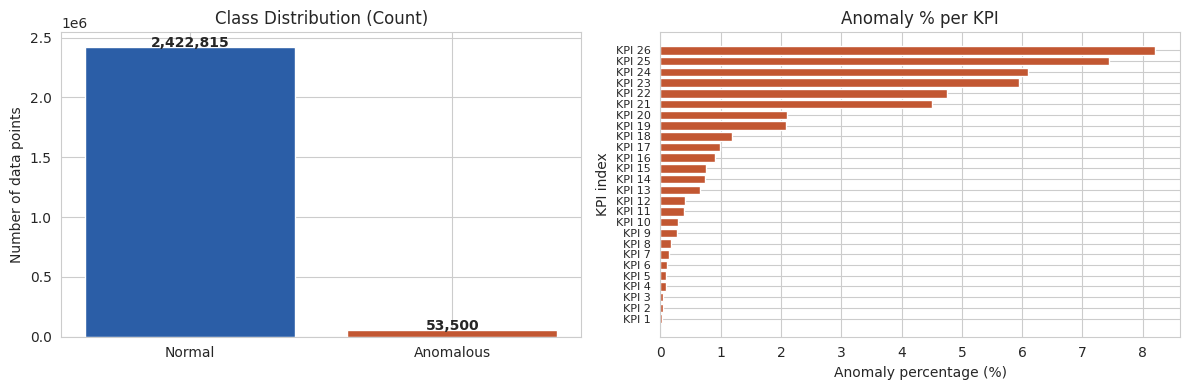

In [9]:
# Overall class distribution
label_counts = train_df['label'].value_counts()
label_pcts = train_df['label'].value_counts(normalize=True) * 100

print('Overall class distribution:')
print(f'  Normal (0):    {label_counts[0]:>10,} ({label_pcts[0]:.2f}%)')
print(f'  Anomalous (1): {label_counts[1]:>10,} ({label_pcts[1]:.2f}%)')
print(f'  Ratio:         1 anomaly per {label_counts[0] // label_counts[1]} normal points')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2B5EA7', '#C25732']
axes[0].bar(['Normal', 'Anomalous'], label_counts.values, color=colors)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_ylabel('Number of data points')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

# Per-KPI anomaly percentage
kpi_anomaly_pcts = train_df.groupby('KPI ID')['label'].mean() * 100
kpi_anomaly_pcts = kpi_anomaly_pcts.sort_values(ascending=True)
axes[1].barh(range(len(kpi_anomaly_pcts)), kpi_anomaly_pcts.values, color='#C25732')
axes[1].set_title('Anomaly % per KPI')
axes[1].set_xlabel('Anomaly percentage (%)')
axes[1].set_ylabel('KPI index')
axes[1].set_yticks(range(len(kpi_anomaly_pcts)))
axes[1].set_yticklabels([f'KPI {i+1}' for i in range(len(kpi_anomaly_pcts))], fontsize=8)

plt.tight_layout()
plt.show()

## 6. Visualize the Time Series

Now let's see what these KPIs actually look like over time.
This is like opening a Grafana dashboard and looking at the graphs.

Red dots = anomalous points. The ML model needs to learn what makes those red dots different.

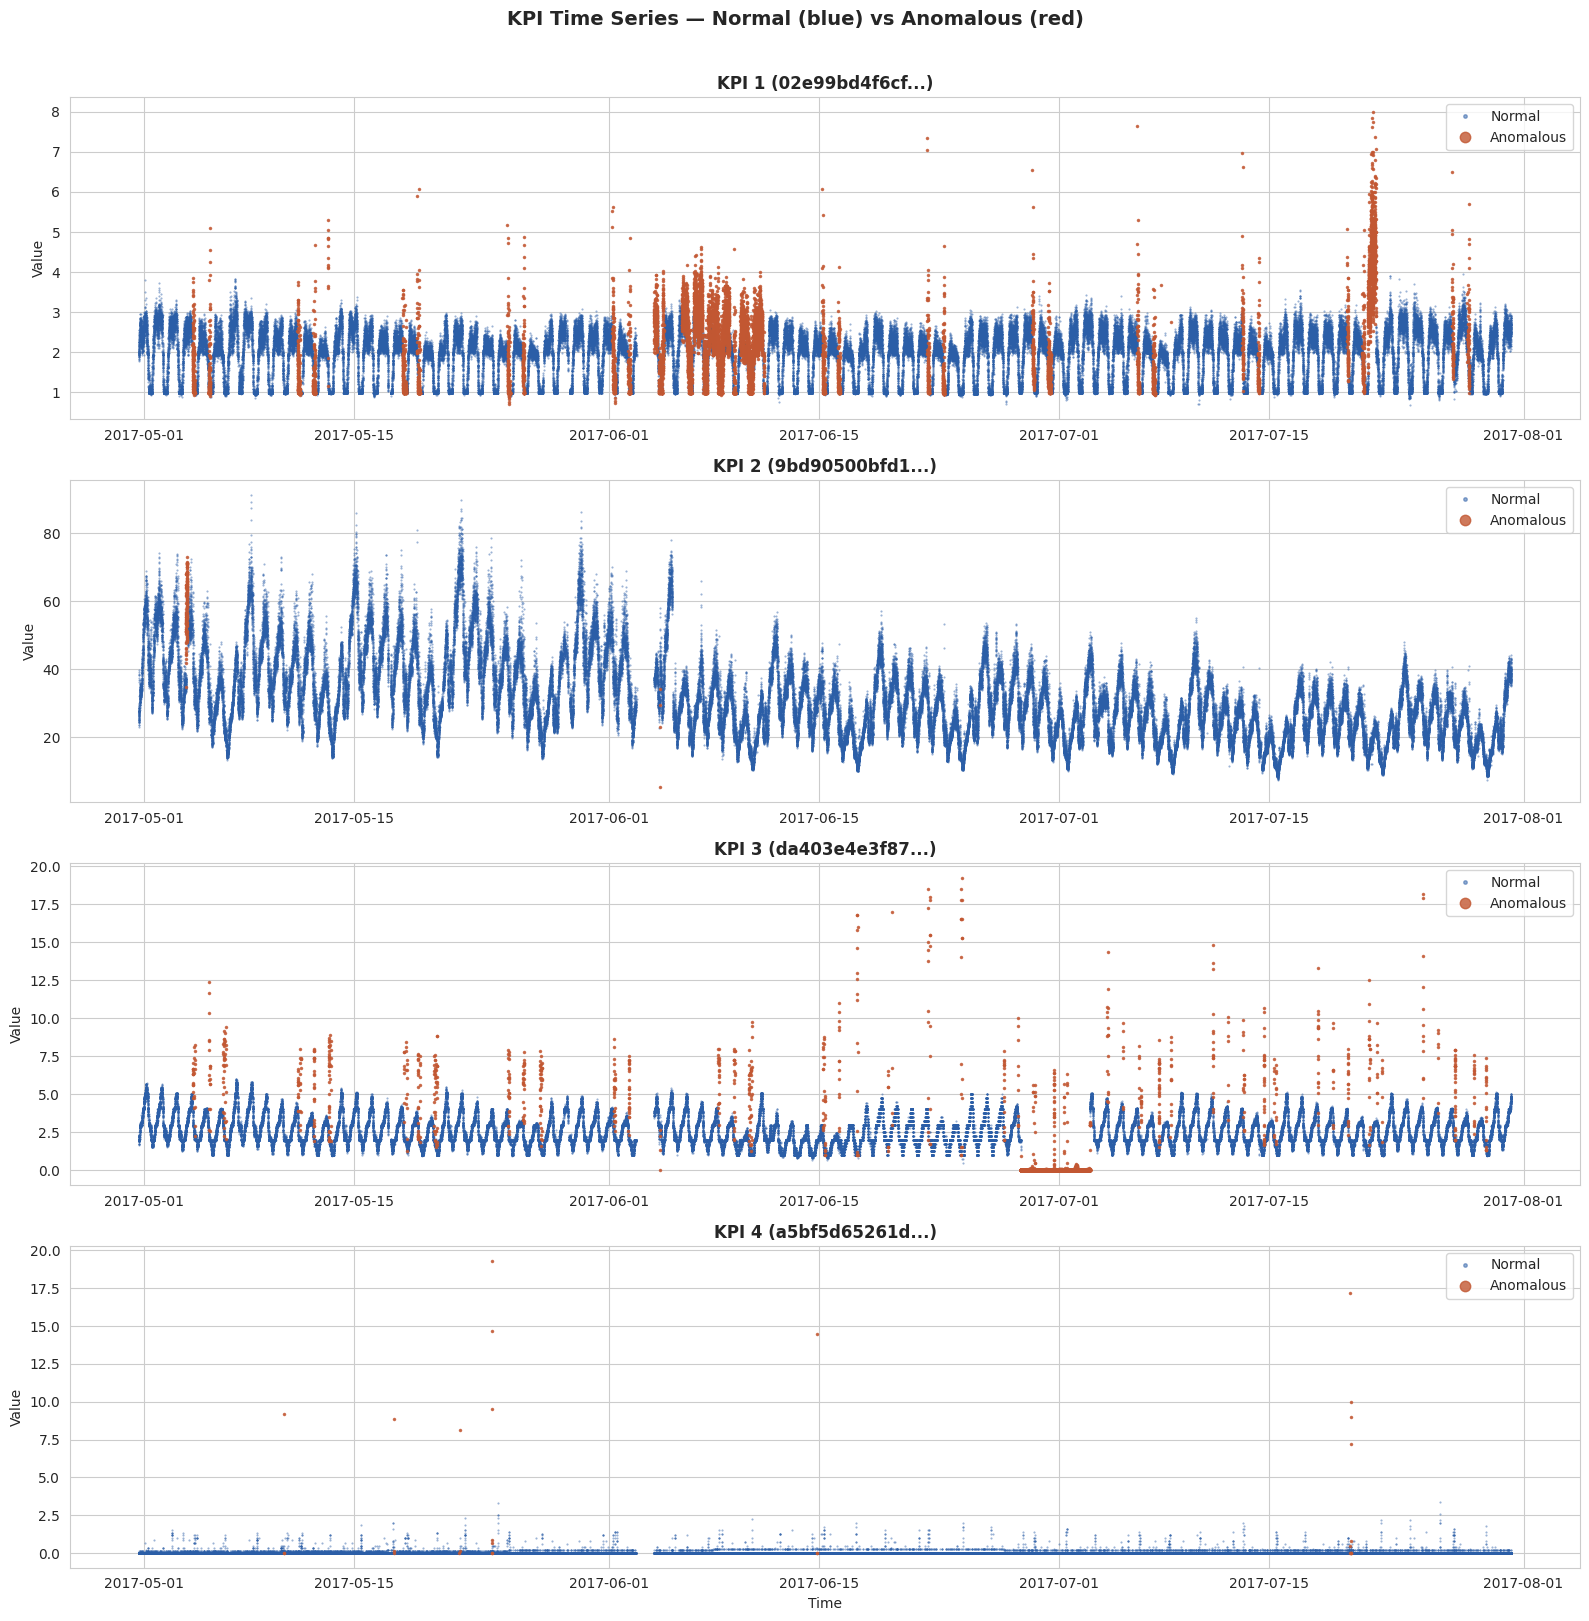

In [10]:
# Convert timestamp to readable datetime
train_df['datetime'] = pd.to_datetime(train_df['timestamp'], unit='s')

# Plot first 4 KPIs
fig, axes = plt.subplots(4, 1, figsize=(16, 16))

for idx, kpi_id in enumerate(kpi_ids[:4]):
    kpi_data = train_df[train_df['KPI ID'] == kpi_id].copy()
    normal = kpi_data[kpi_data['label'] == 0]
    anomalous = kpi_data[kpi_data['label'] == 1]

    axes[idx].plot(normal['datetime'], normal['value'],
                   '.', markersize=1, color='#2B5EA7', alpha=0.5, label='Normal')
    axes[idx].plot(anomalous['datetime'], anomalous['value'],
                   '.', markersize=3, color='#C25732', alpha=0.8, label='Anomalous')
    axes[idx].set_title(f'KPI {idx+1} ({kpi_id[:12]}...)', fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].legend(loc='upper right', markerscale=5)

axes[-1].set_xlabel('Time')
plt.suptitle('KPI Time Series — Normal (blue) vs Anomalous (red)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Zoom Into Anomalies

Let's zoom into one KPI and look at what anomalies look like up close.
Understanding the **shape** of anomalies helps us pick the right ML approach.

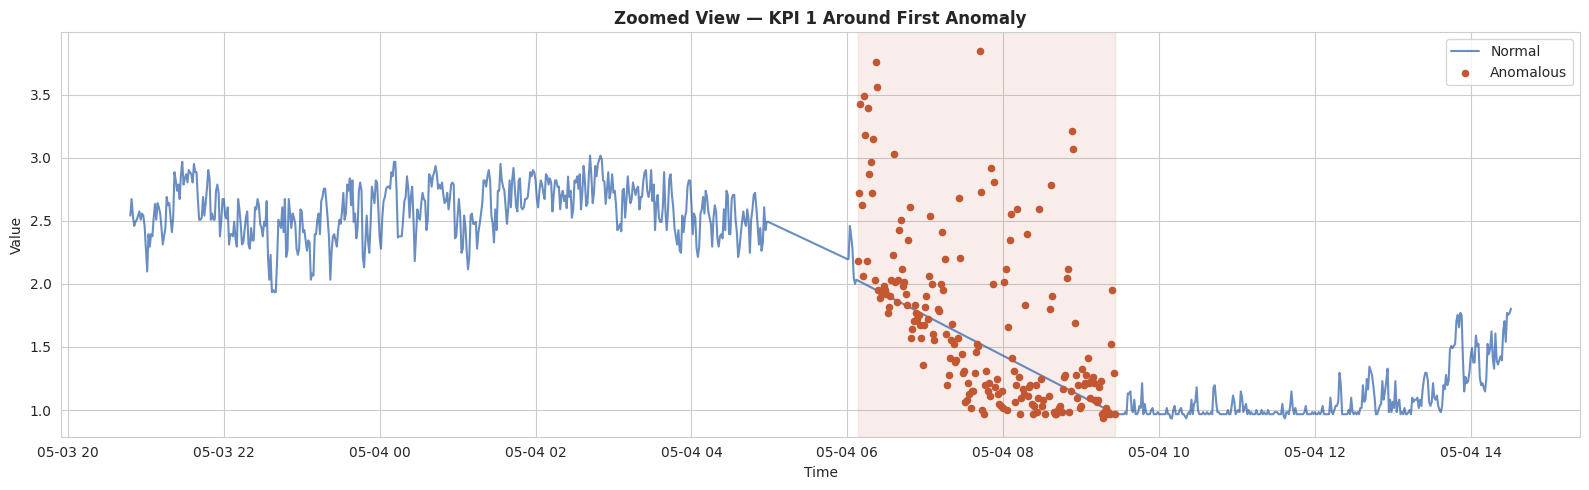

Anomaly window duration: 0 days 03:18:00
Points in window: 1000 (195 anomalous)


In [11]:
# Pick one KPI and zoom into a window around an anomaly
sample_kpi_id = kpi_ids[0]
kpi_data = train_df[train_df['KPI ID'] == sample_kpi_id].copy()
kpi_data = kpi_data.sort_values('timestamp').reset_index(drop=True)

# Find the first anomaly window
anomaly_indices = kpi_data[kpi_data['label'] == 1].index
if len(anomaly_indices) > 0:
    first_anomaly_idx = anomaly_indices[0]
    # Take 500 points before and after
    start = max(0, first_anomaly_idx - 500)
    end = min(len(kpi_data), first_anomaly_idx + 500)
    window = kpi_data.iloc[start:end]

    normal_w = window[window['label'] == 0]
    anomalous_w = window[window['label'] == 1]

    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(normal_w['datetime'], normal_w['value'], '-', color='#2B5EA7', alpha=0.7, label='Normal')
    ax.scatter(anomalous_w['datetime'], anomalous_w['value'],
               color='#C25732', s=20, zorder=5, label='Anomalous')
    ax.set_title(f'Zoomed View — KPI 1 Around First Anomaly', fontweight='bold')
    ax.set_xlabel('Time')
    ax.set_ylabel('Value')
    ax.legend()
    ax.axvspan(anomalous_w['datetime'].min(), anomalous_w['datetime'].max(),
               alpha=0.1, color='#C25732', label='Anomaly window')
    plt.tight_layout()
    plt.show()

    print(f'Anomaly window duration: {anomalous_w["datetime"].max() - anomalous_w["datetime"].min()}')
    print(f'Points in window: {len(window)} ({len(anomalous_w)} anomalous)')

## 8. Statistical Summary per KPI

Let's compare normal vs anomalous data points statistically.
If anomalous points have very different statistical properties,
even simple models might catch them.

In [12]:
# Compare statistics: normal vs anomalous for each KPI
summary_rows = []

for i, kpi_id in enumerate(kpi_ids):
    kpi_data = train_df[train_df['KPI ID'] == kpi_id]
    normal = kpi_data[kpi_data['label'] == 0]['value']
    anomalous = kpi_data[kpi_data['label'] == 1]['value']

    summary_rows.append({
        'KPI': f'KPI {i+1}',
        'Normal Mean': f'{normal.mean():.2f}',
        'Normal Std': f'{normal.std():.2f}',
        'Anomaly Mean': f'{anomalous.mean():.2f}',
        'Anomaly Std': f'{anomalous.std():.2f}',
        'Mean Diff (%)': f'{abs(anomalous.mean() - normal.mean()) / (normal.std() + 1e-8) * 100:.1f}%',
        'Anomaly %': f'{len(anomalous) / len(kpi_data) * 100:.2f}%'
    })

summary_df = pd.DataFrame(summary_rows)
print('Normal vs Anomalous — Statistical Comparison')
print('=' * 90)
print(summary_df.to_string(index=False))

Normal vs Anomalous — Statistical Comparison
   KPI   Normal Mean   Normal Std  Anomaly Mean  Anomaly Std Mean Diff (%) Anomaly %
 KPI 1          1.93         0.61          2.19         0.99         43.5%     8.21%
 KPI 2         31.58        11.83         58.61        10.03        228.5%     0.11%
 KPI 3          2.57         0.95          0.84         2.32        182.8%     5.94%
 KPI 4          0.01         0.08          4.51         6.15       5757.8%     0.02%
 KPI 5          4.19         1.51          5.88        33.24        112.0%     6.09%
 KPI 6 1025153532.81 155225334.28 1013084979.90 150376501.83          7.8%     0.18%
 KPI 7 1051418015.88  92932974.89 1016157125.16  76553014.62         37.9%     0.10%
 KPI 8       1243.29        64.53       1453.70       340.38        326.1%     7.44%
 KPI 9         -0.01         0.95         -1.32         0.74        137.4%     0.91%
KPI 10          0.17         1.04         -1.06         1.19        118.3%     1.19%
KPI 11         -0.13

## 9. Scrape Interval Analysis

Like Prometheus, these KPIs are scraped at regular intervals.
Let's verify the scrape interval — this tells us the time resolution of our data.

In [13]:
# Check scrape interval for each KPI
for i, kpi_id in enumerate(kpi_ids[:6]):
    kpi_data = train_df[train_df['KPI ID'] == kpi_id].sort_values('timestamp')
    intervals = kpi_data['timestamp'].diff().dropna()
    common_interval = intervals.mode()[0]
    print(f'KPI {i+1}: interval = {int(common_interval)}s ({int(common_interval/60)}min) | '
          f'time span = {(kpi_data["timestamp"].max() - kpi_data["timestamp"].min()) / 86400:.1f} days')

KPI 1: interval = 60s (1min) | time span = 91.5 days
KPI 2: interval = 60s (1min) | time span = 91.5 days
KPI 3: interval = 60s (1min) | time span = 91.5 days
KPI 4: interval = 60s (1min) | time span = 91.5 days
KPI 5: interval = 60s (1min) | time span = 91.5 days
KPI 6: interval = 60s (1min) | time span = 91.5 days


## Summary
#
# Key findings from this exploration:
# - 26 KPIs, ~2.16% anomalous overall (highly imbalanced)
# - Anomaly rates vary widely across KPIs (some <1%, some >5%)
# - 1-minute scrape interval
# - Anomalies manifest as pattern changes, not just simple spikes
# - No missing values in the dataset
#
# **Next**: `02_baseline_and_features.ipynb` — Feature engineering & threshold baseline